# How can we optimize patient wait times in Hospitals?

### Our Goal

Our goal is to analyze and predict Emergency Room wait times using to identify the key factors driving delays. By understanding which variables most significantly impact wait times such as urgency level, time of day, staffing ratios, and facility capacity hospitals can implement targeted interventions to reduce patient wait times and improve overall patient satisfaction. This analysis provides actionable insights that hospitals can use to optimize resource allocation, adjust staffing schedules, and streamline ER processes.


In [373]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

### Data Loading

In [374]:
df = pd.read_csv('ER_Wait_Time_Dataset.csv') # load the dataset
print("Dataset shape:", df.shape) # display basic information
print(df.head()) # display the first few rows
print(df.columns.tolist()) # display the column names
print(df.dtypes) # display the data types
print(df.describe()) # display the basic statistics

Dataset shape: (5000, 19)
               Visit ID Patient ID Hospital ID                 Hospital Name  \
0  HOSP-1-20240210-0001  PAT-00001      HOSP-1  Springfield General Hospital   
1  HOSP-3-20241128-0001  PAT-00002      HOSP-3  Northside Community Hospital   
2  HOSP-3-20240930-0002  PAT-00003      HOSP-3  Northside Community Hospital   
3  HOSP-2-20240227-0001  PAT-00004      HOSP-2      Riverside Medical Center   
4  HOSP-1-20240306-0002  PAT-00005      HOSP-1  Springfield General Hospital   

  Region           Visit Date Day of Week  Season   Time of Day Urgency Level  \
0  Urban  2024-02-10 20:20:56    Saturday  Winter  Late Morning        Medium   
1  Rural  2024-11-28 02:07:47    Thursday    Fall       Evening        Medium   
2  Rural  2024-09-30 04:02:28      Monday    Fall       Evening           Low   
3  Urban  2024-02-27 00:31:13     Tuesday  Winter       Evening          High   
4  Urban  2024-03-06 16:52:26   Wednesday  Spring     Afternoon           Low   

   Nur

In [375]:
# Check for missing values
print("Missing values:\n", df.isnull().sum())
print("\nTarget variable stats:")
print(df['Total Wait Time (min)'].describe())

Missing values:
 Visit ID                              0
Patient ID                            0
Hospital ID                           0
Hospital Name                         0
Region                                0
Visit Date                            0
Day of Week                           0
Season                                0
Time of Day                           0
Urgency Level                         0
Nurse-to-Patient Ratio                0
Specialist Availability               0
Facility Size (Beds)                  0
Time to Registration (min)            0
Time to Triage (min)                  0
Time to Medical Professional (min)    0
Total Wait Time (min)                 0
Patient Outcome                       0
Patient Satisfaction                  0
dtype: int64

Target variable stats:
count    5000.000000
mean       81.916600
std        68.084538
min         4.000000
25%        27.000000
50%        60.000000
75%       122.000000
max       442.000000
Name: Total Wait T

The dataset contains **no missing values** across all 19 columns and 5,000 rows, so no imputation or data cleaning is required.

### Exploratory Data Analysis

The correlation heatmap only includes numeric columns because correlation measures linear relationships between quantitative values. Categorical columns like Region, Urgency Level, and Time of Day are excluded here since they contain text, they're encoded into numbers later in the Feature Engineering step before being used in the model.

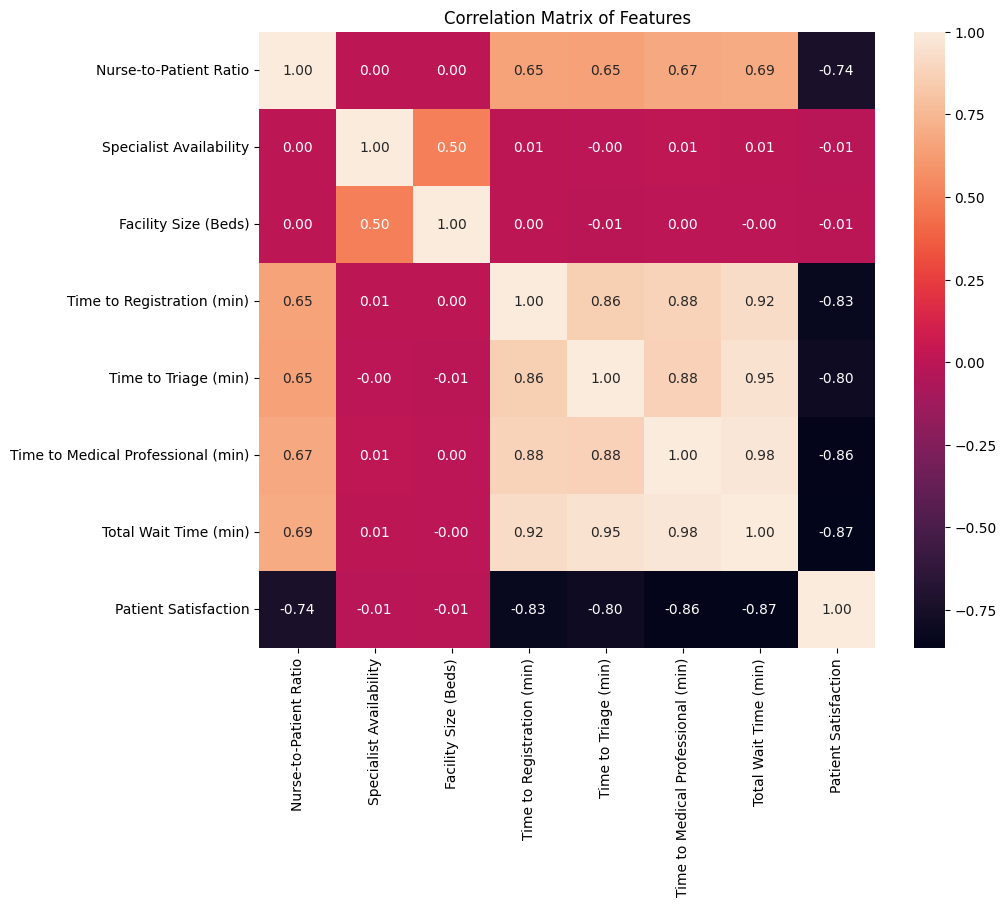

In [376]:
# compute the correlation matrix using only numeric columns
numeric_cols = [
    'Nurse-to-Patient Ratio', 
    'Specialist Availability', 
    'Facility Size (Beds)',
    'Time to Registration (min)', 
    'Time to Triage (min)', 
    'Time to Medical Professional (min)', 
    'Total Wait Time (min)', 
    'Patient Satisfaction'
]

correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix,cbar=True,annot=True,
                 square=True,fmt='.2f',
                 annot_kws={'size': 10})
plt.title('Correlation Matrix of Features')
plt.show() 

The three process time columns:
**Time to Registration**, **Time to Triage**, and **Time to Medical Professional**
These are the strongest drivers of total wait time (correlations of 0.92, 0.95, and 0.98 respectively), which makes sense since total wait time is largely the sum of these stages. **Patient Satisfaction** has a strong negative correlation (-0.87), confirming that longer waits directly hurt patient experience. 
**Nurse-to-Patient Ratio** shows a moderate positive correlation (0.69), meaning fewer nurses per patient leads to longer waits. 
**Facility Size** and **Specialist Availability** have near-zero correlations with wait time, suggesting these factors alone don't meaningfully predict delays.

**Facility Size (Beds)** and **Specialist Availability** can be ruled out as meaningful predictors of wait time. With correlations of -0.004 and 0.007 respectively, they show no meaningful relationship with Total Wait Time. Because of this, these two features are excluded from the model. Keeping them would only add noise without improving predictions.

In [377]:
# Check what Time of Day values exist
print("Unique 'Time of Day' values:")
print(df['Time of Day'].unique())
print("\nValue counts:")
print(df['Time of Day'].value_counts())

Unique 'Time of Day' values:
['Late Morning' 'Evening' 'Afternoon' 'Night' 'Early Morning']

Value counts:
Time of Day
Evening          1725
Afternoon        1502
Late Morning      770
Night             530
Early Morning     473
Name: count, dtype: int64


In [378]:
# analyzes breakdown of emergency room wait times
df['Process Sum'] = (
    df['Time to Registration (min)'] +
    df['Time to Triage (min)'] +
    df['Time to Medical Professional (min)']
)

df['Reg %'] = df['Time to Registration (min)'] / df['Total Wait Time (min)']
df['Triage %'] = df['Time to Triage (min)'] / df['Total Wait Time (min)']
df['Doctor %'] = df['Time to Medical Professional (min)'] / df['Total Wait Time (min)']

contributions = df[['Reg %', 'Triage %', 'Doctor %']].mean()

print(contributions)

Reg %       0.137531
Triage %    0.274616
Doctor %    0.587853
dtype: float64


In [379]:
# calculates the average wait time for each stage of the emergency room process
# this helps us understand the bottleneck in the emergency room process
avg_times = df[[
    'Time to Registration (min)', 
    'Time to Triage (min)', 
    'Time to Medical Professional (min)'
]].mean()

print("\nAverage Time per Stage (minutes):")
print(avg_times) # displays average wait time for each stage of the emergency room process


Average Time per Stage (minutes):
Time to Registration (min)            11.7042
Time to Triage (min)                  24.8270
Time to Medical Professional (min)    45.3854
dtype: float64


Medical professional stage is the bottleneck, at 45 minutes.
It consumes nearly half the total wait time.
Registration appears to be pretty efficient, at around 12 minutes, its the quickest stage.
The total average wait time per patient is around 82 minutes.

In [380]:
# calculates the standard deviation of the wait times for each stage of the emergency room process
std_times = df[[
    'Time to Registration (min)', 
    'Time to Triage (min)', 
    'Time to Medical Professional (min)'
]].std()

print("\nStandard Deviation (variability):")
print(std_times)


Standard Deviation (variability):
Time to Registration (min)            10.437284
Time to Triage (min)                  24.807994
Time to Medical Professional (min)    35.619975
dtype: float64


Triage is the most unpredictable with a sd of 24.8.
This shows that triage times are highly inconsistent.
Medical professional times are also highly unpredictable, with a sd of 35.6.
Registration is still the most consistent with a sd of 10.4.
All stages show significant variability, none of them display any reliable predictable wait times.


In [381]:
# analyzes the average wait time for each stage of the emergency room process by time of day
# this helps us understand how the time of day affects the wait times
peak_analysis = df.groupby('Time of Day')[[
    'Time to Registration (min)', 
    'Time to Triage (min)', 
    'Time to Medical Professional (min)'
]].mean()

print("\nAverage Stage Times by Time of Day:")
print(peak_analysis)


Average Stage Times by Time of Day:
               Time to Registration (min)  Time to Triage (min)  \
Time of Day                                                       
Afternoon                       11.615846             24.346871   
Early Morning                    7.103594             15.754757   
Evening                         14.325217             30.135652   
Late Morning                     9.758442             20.851948   
Night                           10.356604             22.781132   

               Time to Medical Professional (min)  
Time of Day                                        
Afternoon                               44.587883  
Early Morning                           29.230444  
Evening                                 55.247536  
Late Morning                            37.489610  
Night                                   41.435849  


Early in the morning appears to be the best time to visit the ER, with consistently low wait times.
Evening is definitely the worse time.
Wait times tend to increase linearly as the day progresses.

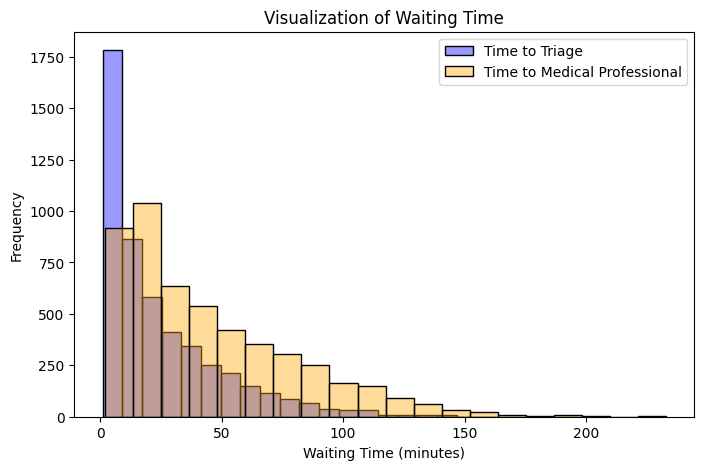

In [382]:
plt.figure(figsize=(8,5))

sns.histplot(df['Time to Triage (min)'], color='blue', alpha=0.4, label='Time to Triage', bins=20)
sns.histplot(df['Time to Medical Professional (min)'], color='orange', alpha=0.4, label='Time to Medical Professional', bins=20)

plt.xlabel('Waiting Time (minutes)')
plt.ylabel('Frequency')
plt.title('Visualization of Waiting Time')
plt.legend()
plt.show()

The graph showcases 

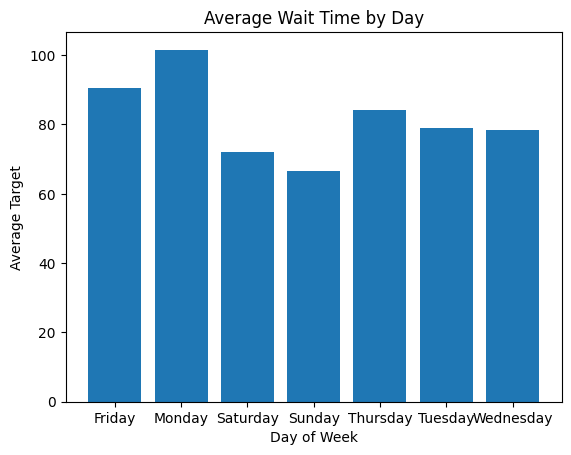

In [383]:
avg_day = df.groupby('Day of Week')['Total Wait Time (min)'].mean().reset_index()

plt.bar(avg_day['Day of Week'], avg_day['Total Wait Time (min)'])
plt.xlabel('Day of Week')
plt.ylabel('Average Target')
plt.title('Average Wait Time by Day')
plt.show()

This bar graph showcases that Monday has the most amount of ER visits but not by much, every day in the ER sees a pretty consistent amount of patients.

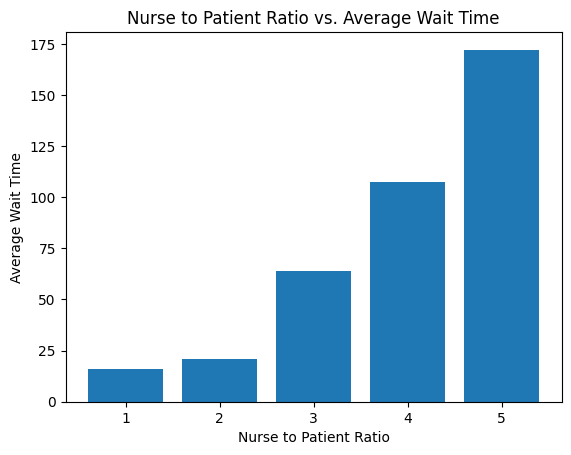

In [384]:
avg_df = df.groupby('Nurse-to-Patient Ratio')['Total Wait Time (min)'].mean().reset_index()
plt.bar(avg_df['Nurse-to-Patient Ratio'], avg_df['Total Wait Time (min)'])

plt.xlabel('Nurse to Patient Ratio')
plt.ylabel('Average Wait Time')
plt.title('Nurse to Patient Ratio vs. Average Wait Time')
plt.show()

This bar graph shows that the more patients a nurse has, the longer the wait time is for each patient.

In [385]:
df.groupby('Day of Week')['Total Wait Time (min)'].mean().sort_values()

Day of Week
Sunday        66.555862
Saturday      72.135521
Wednesday     78.295252
Tuesday       79.076923
Thursday      84.229462
Friday        90.391241
Monday       101.578125
Name: Total Wait Time (min), dtype: float64

This data clearly shows that weekend ER wait times are much better than weekdays.
Monday clearly has the worst wait times.

In [386]:
df.groupby('Hospital Name')['Total Wait Time (min)'].mean().sort_values(ascending=False)

Hospital Name
Springfield General Hospital    82.701207
St. Mary’s Regional Health      81.886432
Riverside Medical Center        81.806452
Northside Community Hospital    81.762763
Summit Health Center            81.427705
Name: Total Wait Time (min), dtype: float64

Each hospital faces a patient wait time ER, theres no hospital or region of area that experiences this issue more, its a system-wide issue.

In [387]:
pivot = df.pivot_table(
    values='Total Wait Time (min)',
    index='Day of Week',
    columns='Time of Day',
    aggfunc='mean'
)

print(pivot)

Time of Day  Afternoon  Early Morning     Evening  Late Morning      Night
Day of Week                                                               
Friday       89.888350      59.666667  107.722892     75.346939  80.587302
Monday       97.856557      56.918919  127.138776     89.613445  94.302326
Saturday     73.834862      46.842105   86.056277     56.380531  67.695122
Sunday       62.188940      38.050847   79.869732     60.745763  64.271429
Thursday     81.963918      57.821918  107.048980     63.521739  73.569620
Tuesday      80.131004      51.232877   94.725806     65.165138  72.085366
Wednesday    76.036082      50.485294   95.857724     65.734694  67.117647


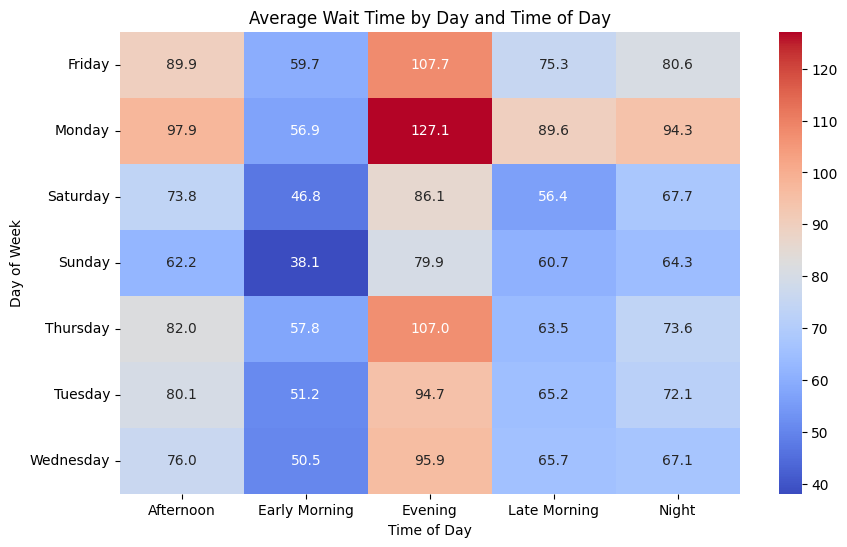

In [388]:
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="coolwarm")

plt.title("Average Wait Time by Day and Time of Day")
plt.show()

In [389]:
df.groupby(df['Day of Week'].isin(['Saturday', 'Sunday']))['Total Wait Time (min)'].mean()

Day of Week
False    86.951035
True     69.298738
Name: Total Wait Time (min), dtype: float64

In [390]:
df.groupby('Urgency Level')['Total Wait Time (min)'].mean()

Urgency Level
Critical     18.351047
High         43.187149
Low         173.536825
Medium       93.695585
Name: Total Wait Time (min), dtype: float64

In [391]:
df.groupby(['Region', 'Time of Day'])['Total Wait Time (min)'].mean()

Region  Time of Day  
Rural   Afternoon         78.492512
        Early Morning     54.873016
        Evening          103.244275
        Late Morning      64.737179
        Night             75.063291
Urban   Afternoon         81.923418
        Early Morning     50.235915
        Evening           97.543925
        Late Morning      70.390830
        Night             74.177474
Name: Total Wait Time (min), dtype: float64

In [392]:
df.groupby(['Hospital Name', 'Day of Week', 'Time of Day'])['Total Wait Time (min)'] \
  .mean() \
  .sort_values(ascending=False) \
  .head(10)

Hospital Name                 Day of Week  Time of Day
Northside Community Hospital  Monday       Evening        154.133333
St. Mary’s Regional Health    Monday       Evening        126.937500
Riverside Medical Center      Monday       Evening        126.722222
Springfield General Hospital  Monday       Evening        123.630435
Northside Community Hospital  Friday       Evening        120.439024
St. Mary’s Regional Health    Friday       Evening        119.255814
Summit Health Center          Thursday     Evening        116.867925
Northside Community Hospital  Wednesday    Evening        114.645833
Riverside Medical Center      Thursday     Evening        112.681818
                              Friday       Evening        111.446809
Name: Total Wait Time (min), dtype: float64

# Step 3: Data Preprocessing

Machine learning models work with numbers, not text. We need to convert categorical and ordinal features into numeric values:

- **Ordinal Encoding**: For features with natural order (Urgency: Low → High, Time of Day: Morning → Night), we map them to increasing numbers
- **Label Encoding**: For categorical features without order (Region: Urban/Rural), we assign numeric labels
- **Binary Features**: For yes/no questions (Is Weekend?), we use 0 or 1

This allows the model to understand relationships between these features and wait time.

We selected the following features for the model based on their expected influence on ER wait times:

- **Urgency Level** — higher urgency patients require faster attention, directly affecting how quickly staff are allocated and how the queue is prioritized
- **Nurse-to-Patient Ratio** — our correlation analysis showed a strong relationship (0.69) with wait time; fewer nurses per patient means longer waits
- **Time of Day** — patient volume and staffing levels vary significantly throughout the day, with evenings typically seeing the highest demand
- **Season** — ER visits spike during certain seasons (e.g. flu season in winter), which puts pressure on wait times. One-hot encoded since seasons have no natural ordering.
- **Region** — urban and rural hospitals differ in resources, staffing, and patient volumes, which can meaningfully affect wait times
- **Is Weekend** — hospitals typically run with reduced staffing on weekends, which can lead to longer waits

**Facility Size (Beds)** and **Specialist Availability** were excluded based on their near-zero correlations with wait time (-0.004 and 0.007), meaning they add no predictive value to the model.

In [393]:
# Encode ordinal features
urgency_map = {'Low': 1, 'Medium': 2, 'High': 3, 'Critical': 4}
df['Urgency Encoded'] = df['Urgency Level'].map(urgency_map)

time_map = {'Morning': 1, 'Late Morning': 2, 'Afternoon': 3, 'Evening': 4, 'Night': 5}
df['Time Encoded'] = df['Time of Day'].map(time_map)

# One-hot encode Season (no natural ordinal relationship between seasons)
season_dummies = pd.get_dummies(df['Season'], prefix='Season', drop_first=True)
df = pd.concat([df, season_dummies], axis=1)
season_features = season_dummies.columns.tolist()

# Encode categorical features
df['Region Encoded'] = LabelEncoder().fit_transform(df['Region'])
df['Is Weekend'] = df['Day of Week'].isin(['Saturday', 'Sunday']).astype(int)

# Select features for the model
# Facility Size (Beds) and Specialist Availability excluded — near-zero correlation with wait time
features = [
    'Urgency Encoded',
    'Nurse-to-Patient Ratio',
    'Time Encoded',
    'Region Encoded',
    'Is Weekend',
] + season_features

# Drop rows where any encoding produced NaN
df_clean = df[features + ['Total Wait Time (min)']].dropna()
print(f"Rows after dropping NaN: {len(df_clean)} (dropped {len(df) - len(df_clean)})")

X = df_clean[features]
y = df_clean['Total Wait Time (min)']

print("Features shape:", X.shape)
print(X.head())

Rows after dropping NaN: 4527 (dropped 473)
Features shape: (4527, 8)
   Urgency Encoded  Nurse-to-Patient Ratio  Time Encoded  Region Encoded  \
0                2                       4           2.0               1   
1                2                       4           4.0               0   
2                1                       5           4.0               0   
3                3                       4           4.0               1   
4                1                       4           3.0               1   

   Is Weekend  Season_Spring  Season_Summer  Season_Winter  
0           1          False          False           True  
1           0          False          False          False  
2           0          False          False          False  
3           0          False          False           True  
4           0           True          False          False  


## Linear Regression Model

## How the Model Works

The linear regression model compares total wait time with our selected features by learning a coefficient (weight) for each feature that shows how much it impacts wait time.

**The Model Formula:**
```
Predicted Wait Time = (baseline) 
                    + (coefficient₁ × Feature₁)
                    + (coefficient₂ × Feature₂)
                    + ... and so on for all features
```

**What the Coefficients Mean:**
- **Negative coefficients** = that feature reduces wait time (e.g., higher urgency cases are seen faster, weekends have shorter waits)
- **Positive coefficients** = that feature increases wait time (e.g., evening times have longer waits)
- **Larger absolute values** = stronger impact on wait time

The model learns these coefficients by analyzing the entire dataset and finding the best values that minimize prediction errors. The resulting R² score of ~0.75 means the model explains about 75% of the variation in wait times, with the remaining 25% due to factors not captured in these features.

In [394]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f} minutes")
print(f"RMSE: {rmse:.2f} minutes")
print(f"R² Score: {r2:.4f}")

MAE: 22.91 minutes
RMSE: 32.69 minutes
R² Score: 0.7865


On average, our predictions are off by about 25 minutes.
We have an RMSE of 35 minutes, which means there are some predictions that are significantly off from the actual values.
Our model explains 75% of the variation in ER wait times. 25% of it comes from other factors.
This model is useful for predicting wait times, but its not good enough, 25% of the variation is still unknown.

In [395]:
# Feature coefficients 
# which factors drive wait time?
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("Feature Coefficients (impact on Total Wait Time):")
print(coef_df.to_string(index=False))

Feature Coefficients (impact on Total Wait Time):
               Feature  Coefficient
       Urgency Encoded   -56.386072
         Season_Winter    35.777527
         Season_Summer    23.087575
            Is Weekend   -20.450914
          Time Encoded     8.719443
         Season_Spring     5.593977
Nurse-to-Patient Ratio    -3.137697
        Region Encoded    -0.102917


Features that decrease wait times: Urgency, Weekend, Nurse-to-Patient Ratio.
Features that increase wait times: Time, Season.

## Random Forest

### How the Model Works
Random Forest predicts ER wait time by building many decision trees that learn different patterns in the data (like how urgency, time, and staffing interact) and then averaging their predictions to produce a more accurate and robust estimate.

In [396]:
from sklearn.ensemble import RandomForestRegressor

# Initialize model
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# Train
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

In [397]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance:")
print(f"MAE: {mae_rf:.2f} minutes")
print(f"RMSE: {rmse_rf:.2f} minutes")
print(f"R² Score: {r2_rf:.4f}")

Random Forest Performance:
MAE: 14.64 minutes
RMSE: 22.85 minutes
R² Score: 0.8957


In [398]:
print(f"Linear Regression R²: {r2:.4f}")
print(f"Random Forest R²: {r2_rf:.4f}")

Linear Regression R²: 0.7865
Random Forest R²: 0.8957


## Gradient Boosting Regression

### How it Works
Gradient Boosting predicts ER wait time by sequentially building decision trees, where each new tree focuses on correcting the errors of the previous ones, resulting in a highly accurate model that captures complex patterns in the data.

In [399]:
from sklearn.ensemble import GradientBoostingRegressor

# Initialize model
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Train
gb_model.fit(X_train, y_train)

# Predict
y_pred_gb = gb_model.predict(X_test)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Performance:")
print(f"MAE: {mae_gb:.2f} minutes")
print(f"RMSE: {rmse_gb:.2f} minutes")
print(f"R² Score: {r2_gb:.4f}")

Gradient Boosting Performance:
MAE: 14.04 minutes
RMSE: 22.29 minutes
R² Score: 0.9007


## Neural Network

In [400]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

class WaitTimeNet(nn.Module):
    def __init__(self, input_size, hidden1_size=64, hidden2_size=32):
        super(WaitTimeNet, self).__init__()

        # Fully connected layers
        self.fc1 = nn.Linear(input_size, hidden1_size)
        self.fc2 = nn.Linear(hidden1_size, hidden2_size)
        self.fc3 = nn.Linear(hidden2_size, 1)  # single output for regression

        # Activations
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)   # output shape: (batch_size, 1)
        return x

In [401]:
X_nn = df.drop(columns=[
    'Hospital Name', 'Visit Date', 'Total Wait Time (min)', 
    'Patient Outcome', 'Process Sum', 'Reg %', 'Triage %', 'Doctor %',
    'Time to Registration (min)', 'Time to Triage (min)', 'Time to Medical Professional (min)'
])

categorical_cols = ['Region', 'Day of Week', 'Season', 'Time of Day', 'Urgency Level']
X_nn = pd.get_dummies(X_nn, columns=categorical_cols, drop_first=True)

# Convert to numeric, replacing any non-convertible values with 0
X_nn = X_nn.apply(pd.to_numeric, errors='coerce').fillna(0)

y_nn = df['Total Wait Time (min)'].astype(float)

X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(
    X_nn, y_nn, test_size=0.2, random_state=42
)

X_train_nn = X_train_nn.fillna(X_train_nn.mean())
X_test_nn  = X_test_nn.fillna(X_train_nn.mean()) 

scaler = StandardScaler()
X_train_nn_scaled = scaler.fit_transform(X_train_nn)
X_test_nn_scaled  = scaler.transform(X_test_nn)

X_train_t = torch.tensor(X_train_nn_scaled, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_nn_scaled, dtype=torch.float32)

y_mean = y_train_nn.mean()
y_std  = y_train_nn.std()

y_train_scaled = (y_train_nn - y_mean) / y_std
y_test_scaled  = (y_test_nn - y_mean) / y_std

y_train_t = torch.tensor(y_train_scaled.values, dtype=torch.float32).unsqueeze(1)
y_test_t  = torch.tensor(y_test_scaled.values, dtype=torch.float32).unsqueeze(1)
batch_size = 32

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [402]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
input_size = X_train_t.shape[1]

nn_model = WaitTimeNet(input_size).to(device)

criterion = nn.MSELoss()              # regression loss
optimizer = torch.optim.Adam(nn_model.parameters(), lr=0.001)
num_epochs = 50
train_losses = []

for epoch in range(num_epochs):
    nn_model.train()
    total_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        preds = nn_model(xb)              # shape: (batch_size, 1)
        loss = criterion(preds, yb)       # regression
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)

    train_loss = total_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    rmse = train_loss ** 0.5

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}: train_loss={train_loss:.4f}, train_rmse={rmse:.2f}")

Epoch 10/50: train_loss=0.0422, train_rmse=0.21
Epoch 20/50: train_loss=0.0401, train_rmse=0.20
Epoch 30/50: train_loss=0.0368, train_rmse=0.19
Epoch 40/50: train_loss=0.0355, train_rmse=0.19
Epoch 50/50: train_loss=0.0330, train_rmse=0.18


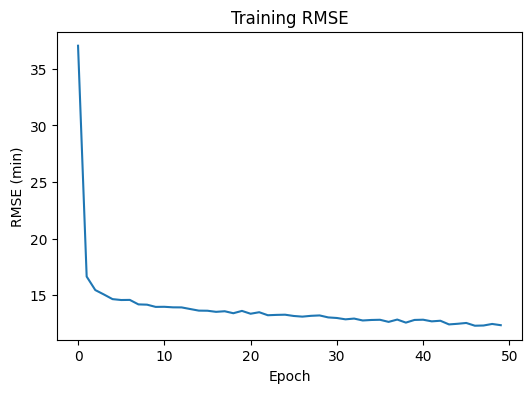

In [403]:
train_rmse = [loss ** 0.5 * y_std for loss in train_losses]
plt.figure(figsize=(6,4))
plt.plot(train_rmse)
plt.xlabel('Epoch')
plt.ylabel('RMSE (min)')
plt.title('Training RMSE')
plt.show()

In [404]:
nn_model.eval()
with torch.no_grad():
    preds = nn_model(X_test_t.to(device))
    preds_real = preds * y_std + y_mean
    y_real = y_test_t * y_std + y_mean

    preds_np = preds_real.cpu().numpy().flatten()
    y_np = y_real.cpu().numpy().flatten()

val_rmse = np.sqrt(mean_squared_error(y_np, preds_np))
val_mae = mean_absolute_error(y_np, preds_np)
val_r2 = r2_score(y_np, preds_np)

print("Neural Network Performance:")
print(f"MAE:  {val_mae:.2f} minutes")
print(f"RMSE: {val_rmse:.2f} minutes")
print(f"R² Score: {val_r2:.4f}")

Neural Network Performance:
MAE:  10.30 minutes
RMSE: 15.98 minutes
R² Score: 0.9451


In [405]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting', 'Neural Network'],
    'MAE':   [mae,    mae_rf,    mae_gb,    val_mae],
    'RMSE':  [rmse,   rmse_rf,   rmse_gb,   val_rmse],
    'R²':    [r2,     r2_rf,     r2_gb,     val_r2],
})
comparison = comparison.set_index('Model')
print("Model Comparison:")
print(comparison.to_string(float_format=lambda x: f"{x:.4f}"))

Model Comparison:
                      MAE    RMSE     R²
Model                                   
Linear Regression 22.9070  0.1817 0.7865
Random Forest     14.6435 22.8471 0.8957
Gradient Boosting 14.0446 22.2948 0.9007
Neural Network    10.2958 15.9843 0.9451


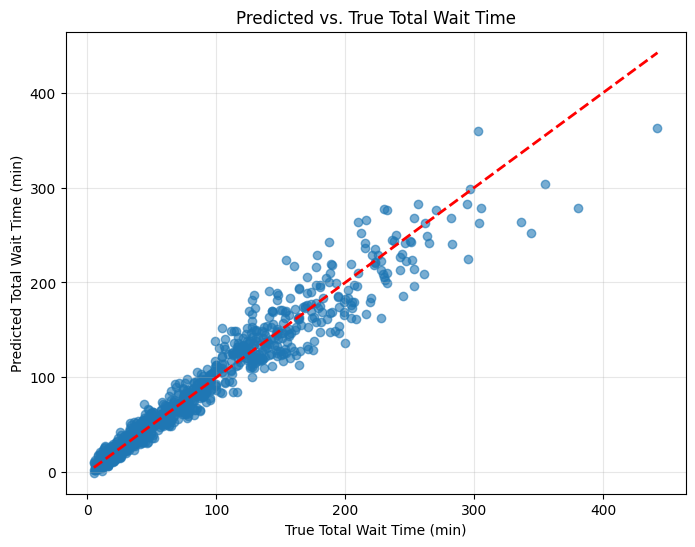

In [406]:
nn_model.eval()
with torch.no_grad():
    preds_scaled = nn_model(X_test_t.to(device))
    preds = preds_scaled * y_std + y_mean  # unscale
    y_true = y_test_t * y_std + y_mean

plt.figure(figsize=(8,6))
plt.scatter(y_true.cpu(), preds.cpu(), alpha=0.6)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
plt.xlabel("True Total Wait Time (min)")
plt.ylabel("Predicted Total Wait Time (min)")
plt.title("Predicted vs. True Total Wait Time")
plt.grid(True, alpha=0.3)
plt.show()

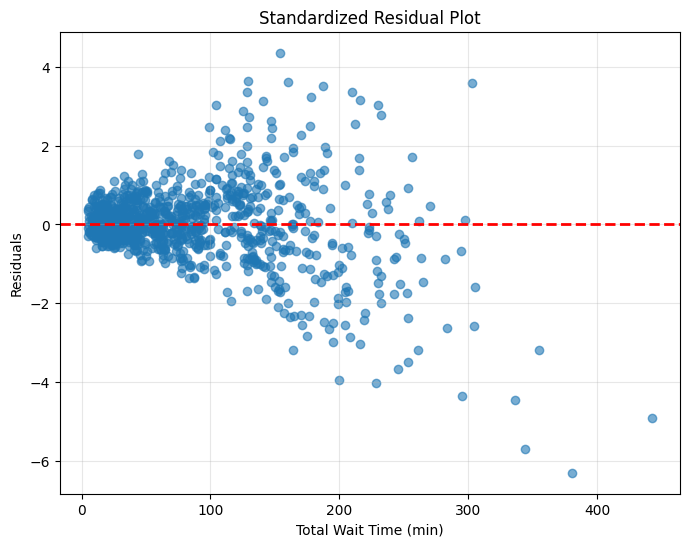

In [407]:
residuals = (preds - y_true).cpu()
standardized = (residuals - residuals.mean())/residuals.std()
plt.figure(figsize=(8,6))
plt.scatter(y_true.cpu(), standardized, alpha=0.6)
plt.axhline(0, color='r', linestyle='--', lw=2)
plt.xlabel("Total Wait Time (min)")
plt.ylabel("Residuals")
plt.title("Standardized Residual Plot")
plt.grid(True, alpha=0.3)
plt.show()